In [1]:
import numpy as np
import simpful
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
# Initialize the fuzzy system
FS = simpful.FuzzySystem(show_banner=False)

## Entry variables

### Central occupation
Based on the number of pieces that occupy central squares

In [3]:
# Central occupation (difference between white and black pieces)
black_occupation = simpful.FuzzySet(
    points=[[-4, 1.0], [-2, 1.0], [0, 0.0]],
    term="black",
)
equal_occupation = simpful.TriangleFuzzySet(-2, 0, 2, term="equal")
white_occupation = simpful.FuzzySet(
    points=[[0, 0.0], [2, 1.0], [4, 1.0]], term="white"
)

FS.add_linguistic_variable(
    "Occupation_Diff",
    simpful.LinguisticVariable(
        [black_occupation, equal_occupation, white_occupation],
        universe_of_discourse=[-4, 4],
    ),
)

### Central attacks
Based on the number of pieces that are attacking central squares

In [4]:
black_attacks = simpful.FuzzySet(
    points=[[-10, 1.0], [-6, 1.0], [-3, 0.5], [0, 0.0]], term="black"
)
equal_attacks = simpful.FuzzySet(
    points=[[-6, 0.0], [-3, 0.5], [0, 1], [3, 0.5], [6, 0.0]], term="equal"
)
white_attacks = simpful.FuzzySet(
    points=[[0, 0.0], [3, 0.5], [6, 1.0], [10, 1.0]], term="white"
)

FS.add_linguistic_variable(
    "Attacks_Diff",
    simpful.LinguisticVariable(
        [black_attacks, equal_attacks, white_attacks], universe_of_discourse=[-10, 10]
    ),
)

## Output variable: central control

In [7]:
desired_universe = [-10, 10]
terms = [
    "strongly_black",
    "black",
    "weakly_black",
    "equal",
    "weakly_white",
    "white",
    "strongly_white",
]
n_terms = len(terms)
centers = np.linspace(desired_universe[0], desired_universe[1], n_terms)
width = centers[1] - centers[0]
universe = [desired_universe[0] - width, desired_universe[1] + width]

fuzzy_sets = []

for i in range(n_terms):
    a = centers[i] - width
    b = centers[i]
    c = centers[i] + width

    fuzzy_sets.append(simpful.TriangleFuzzySet(a, b, c, term=terms[i]))

FS.add_linguistic_variable(
    "Central_Control",
    simpful.LinguisticVariable(
        fuzzy_sets,
        universe_of_discourse=universe
    )
)

### Rule system

In [8]:
rules = [
    # Black dominates both criteria
    "IF (Occupation_Diff IS black) AND (Attacks_Diff IS black) THEN (Central_Control IS strongly_black)",
    #
    # Occupation is equal, black is better on attacks
    "IF (Occupation_Diff IS equal) AND (Attacks_Diff IS black) THEN (Central_Control IS black)",
    #
    # Black is better on occupation, equal on attacks
    "IF (Occupation_Diff IS black) AND (Attacks_Diff IS equal) THEN (Central_Control IS weakly_black)",
    #
    # One side is hyperextended
    "IF (Occupation_Diff IS black) AND (Attacks_Diff IS white) THEN (Central_Control IS weakly_white)",
    "IF (Occupation_Diff IS white) AND (Attacks_Diff IS black) THEN (Central_Control IS weakly_black)",
    #
    # Equality on everything
    "IF (Occupation_Diff IS equal) AND (Attacks_Diff IS equal) THEN (Central_Control IS equal)",
    #
    # White is better on one occupation, equal on attacks
    "IF (Occupation_Diff IS white) AND (Attacks_Diff IS equal) THEN (Central_Control IS weakly_white)",
    #
    # Occupation is equal, white is better on attacks
    "IF (Occupation_Diff IS equal) AND (Attacks_Diff IS white) THEN (Central_Control IS white)",
    #
    # White dominates both criteria
    "IF (Occupation_Diff IS white) AND (Attacks_Diff IS white) THEN (Central_Control IS strongly_white)",
]

FS.add_rules(rules)

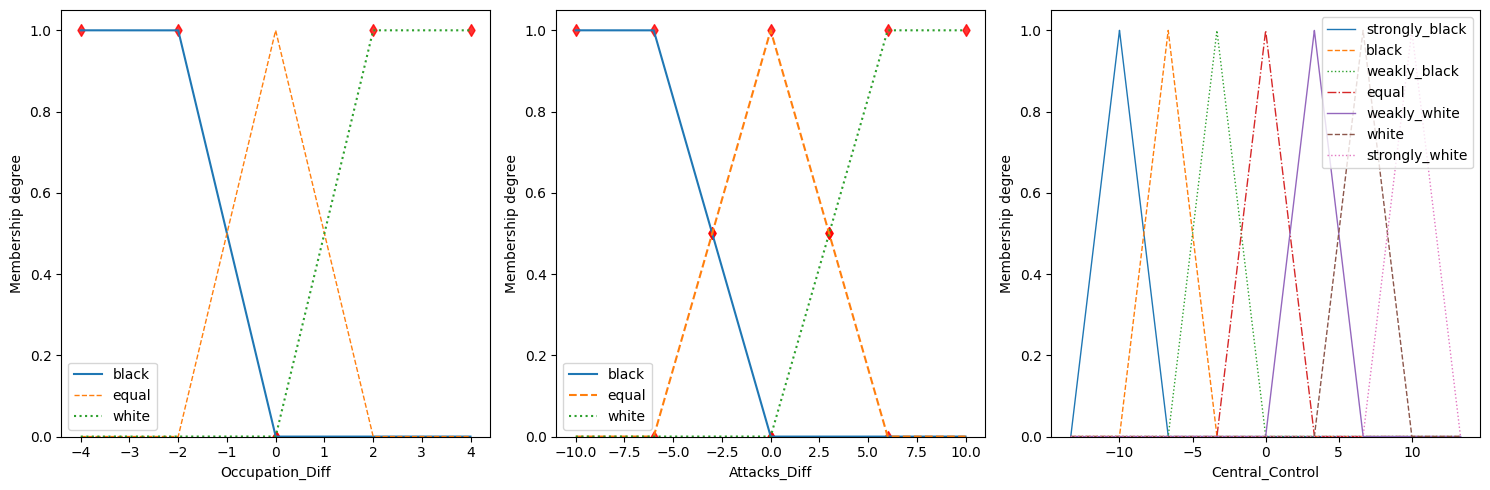

In [9]:
FS.produce_figure()

## Manually testing some scenarios

In [10]:
# Scenario 1: white has more pieces and more attackers on the center
FS.set_variable("Occupation_Diff", 2)
FS.set_variable("Attacks_Diff", 4)

# Perform inference and output evaluation
result = FS.inference()
print(f"Central Control Evaluation: {result["Central_Control"]:.2f}")

Central Control Evaluation: 7.44


In [11]:
# Scenario 2: white has more pieces, but fewer attackers on the center
FS.set_variable("Occupation_Diff", 2)
FS.set_variable("Attacks_Diff", -4)

# Perform inference and output evaluation
result = FS.inference()
print(f"Central Control Evaluation: {result["Central_Control"]:.2f}")

Central Control Evaluation: -0.77


In [12]:
# Scenario 3: white has more pieces, but equal number of attackers on the center
FS.set_variable("Occupation_Diff", 2)
FS.set_variable("Attacks_Diff", 0)

# Perform inference and output evaluation
result = FS.inference()
print(f"Central Control Evaluation: {result["Central_Control"]:.2f}")

Central Control Evaluation: 3.33


In [13]:
# Scenario 4: equality
FS.set_variable("Occupation_Diff",0)
FS.set_variable("Attacks_Diff", 0)

# Perform inference and output evaluation
result = FS.inference()
print(f"Central Control Evaluation: {result["Central_Control"]:.2f}")

Central Control Evaluation: 0.00


## Response surface

### Calculations

In [14]:
# Define grid resolution (higher = smoother surface, but slower to compute)
resolution = 25

# Evaluate fuzzy system on a 2D mesh
# Create the 2D meshgrid
x_attacks = np.linspace(-10, 10, resolution)
y_occupation = np.linspace(-4, 4, resolution)
X, Y = np.meshgrid(x_attacks, y_occupation)
Z = np.zeros_like(X)

# Evaluate the fuzzy system at each point on the mesh
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        FS.set_variable("Attacks_Diff", float(X[i, j]))
        FS.set_variable("Occupation_Diff", float(Y[i, j]))
        
        # Run inference
        result = FS.inference()
        Z[i, j] = result["Central_Control"]

### Configure and show plot

In [ ]:
# Create the interactive 3D plot with Plotly
fig = go.Figure(data=[go.Surface(
    z=Z, 
    x=X, 
    y=Y, 
    colorscale='Viridis',
    showscale=False, # Removes the colorbar on the side
    hovertemplate='Attacks (X): %{x:.2f}<br>Occupation (Y): %{y:.2f}<br>Control (Z): %{z:.2f}<extra></extra>'
)])

# Configure layout, titles, camera, and proportions
fig.update_layout(
    title='Central Control Response Surface',
    scene=dict(
        xaxis_title='Attacks_Diff',
        yaxis_title='Occupation_Diff',
        zaxis_title='Central_Control',
        aspectmode='cube', # Forces the visual base of the plot to be square
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=1.2)
        )
    ),
    width=600, 
    height=500,
    margin=dict(l=10, r=0, b=30, t=40) 
)

fig.show()

## Export FIS as a lookup table for the bot

### Calculate table

In [18]:
# Variable ranges
occupation_range = np.arange(-4, 5)
attacks_range = np.arange(-10, 11)

# Initialize lookup table
center_lut = np.zeros((len(occupation_range), len(attacks_range)))

# Fill matrix evaluating the FIS for every possible combination of inputs
print("Calculating lookup table...")
for i, occ in enumerate(occupation_range):
    for j, att in enumerate(attacks_range):
        FS.set_variable("Occupation_Diff", occ)
        FS.set_variable("Attacks_Diff", att)

        result = FS.inference()
        center_lut[i, j] = result["Central_Control"]

print(f"Lookup table calculated. Shape: {center_lut.shape}.")

Calculating lookup table...
Lookup table calculated. Shape: (9, 21).


### Save table in file

In [19]:
import os

# Make sure the directory exists
os.makedirs("../data/luts", exist_ok=True)

file_path = "../data/luts/center_lut.npy"
np.save(file_path, center_lut)

print(f"Succesfully saved lookup table as {file_path}.")

Succesfully saved lookup table as ../data/luts/center_lut.npy.
